In [ ]:
!pip install pyspark

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("MusicEraDiscovery") \
    .getOrCreate()

sc = spark.sparkContext
print("Spark Version:", spark.version)
print("SparkContext:", sc)

Spark Version: 4.0.2
SparkContext: <SparkContext master=local[*] appName=MusicEraDiscovery>


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving artists.csv to artists.csv
Saving dict_artists.json to dict_artists.json
Saving tracks.csv to tracks.csv


In [ ]:
raw_df = spark.read.csv("tracks.csv", header=True, inferSchema=True)

print("Total Raw Rows:", raw_df.count())
print("Columns:", raw_df.columns)

raw_df.show(5, truncate=False)
raw_df.printSchema()

Total Raw Rows: 586672
Columns: ['id', 'name', 'popularity', 'duration_ms', 'explicit', 'artists', 'id_artists', 'release_date', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
+----------------------+-----------------------------------+----------+-----------+--------+-------------------+--------------------------+------------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+--------------+
|id                    |name                               |popularity|duration_ms|explicit|artists            |id_artists                |release_date|danceability|energy|key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|tempo  |time_signature|
+----------------------+-----------------------------------+----------+-----------+--------+-------------------+--------------------------+------------+------------+------

In [ ]:
from pyspark.sql.functions import col, regexp_extract, floor, when

# Step 1: Extract 4-digit year safely from release_date
raw_df = raw_df.withColumn(
    "year_str",
    regexp_extract(col("release_date"), r"^\d{4}", 0)
)

# Step 2: Replace empty string with null, then cast to int
raw_df = raw_df.withColumn(
    "year",
    when(col("year_str") != "", col("year_str")).cast("int")
)

# Step 3: Select all needed columns using try_cast for numeric safety
df = raw_df.selectExpr(
    "year",
    "name",
    "artists",
    "try_cast(popularity as double) as popularity",
    "try_cast(danceability as double) as danceability",
    "try_cast(energy as double) as energy",
    "try_cast(loudness as double) as loudness",
    "try_cast(speechiness as double) as speechiness",
    "try_cast(acousticness as double) as acousticness",
    "try_cast(instrumentalness as double) as instrumentalness",
    "try_cast(liveness as double) as liveness",
    "try_cast(valence as double) as valence",
    "try_cast(tempo as double) as tempo"
)

# Step 4: Drop rows with nulls
df = df.dropna()

# Step 5: Keep valid year range
df = df.filter((col("year") >= 1920) & (col("year") <= 2020))

# Step 6: Add decade column
df = df.withColumn("decade", (floor(col("year") / 10) * 10).cast("int"))

print("Clean Rows:", df.count())
df.show(5, truncate=False)
df.printSchema()

Clean Rows: 577018
+----+-----------------------------------+-------------------+----------+------------+------+--------+-----------+------------+----------------+--------+-------+-------+------+
|year|name                               |artists            |popularity|danceability|energy|loudness|speechiness|acousticness|instrumentalness|liveness|valence|tempo  |decade|
+----+-----------------------------------+-------------------+----------+------------+------+--------+-----------+------------+----------------+--------+-------+-------+------+
|1922|Carve                              |['Uli']            |6.0       |0.645       |0.445 |-13.338 |0.451      |0.674       |0.744           |0.151   |0.127  |104.851|1920  |
|1922|Capítulo 2.16 - Banquero Anarquista|['Fernando Pessoa']|0.0       |0.695       |0.263 |-22.136 |0.957      |0.797       |0.0             |0.148   |0.655  |102.009|1920  |
|1922|Vivo para Quererte - Remasterizado |['Ignacio Corsini']|0.0       |0.434       |0.177 |-21

In [ ]:
print("=" * 55)
print("PROJECT SUMMARY — CLEAN DATA")
print("=" * 55)

print("Total songs processed :", df.count())
print("Year range            :", df.agg({"year": "min"}).collect()[0][0], "-", df.agg({"year": "max"}).collect()[0][0])
print("Decades covered       :", df.select("decade").distinct().count())

print("\nSongs per decade (top 5 decades by count):")
df.groupBy("decade").count().orderBy(col("count").desc()).show(5)

PROJECT SUMMARY — CLEAN DATA
Total songs processed : 577018
Year range            : 1922 - 2020
Decades covered       : 11

Songs per decade (top 5 decades by count):
+------+------+
|decade| count|
+------+------+
|  1990|108665|
|  2010|104965|
|  2000| 86634|
|  1980| 82132|
|  1970| 61609|
+------+------+
only showing top 5 rows


In [ ]:
from pyspark.ml.feature import VectorAssembler, StandardScaler

feature_cols = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="raw_features"
)

df = assembler.transform(df)

scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="scaled_features",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(df)
df = scaler_model.transform(df)

print("Feature engineering complete.")
df.select("scaled_features").show(3, truncate=False)

Feature engineering complete.
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|scaled_features                                                                                                                                                                      |
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|[0.4945386759104994,-0.3879504626319528,-0.6198973580587852,1.9174974948456056,0.643891147973232,2.3686743516937927,-0.34250759290634447,-1.660497113341262,-0.4595975253229655]     |
|[0.7971184308146531,-1.1114589417069105,-2.3584526901880705,4.719087900052594,0.9970619544372676,-0.4247270060260461,-0.35875202287338587,0.39232036356273753,-0.5551759823322867]   |
|[-0.7823478897850312,-1.4533365746763962,-2.16953

In [ ]:
from pyspark.ml.feature import PCA
from pyspark.ml.functions import vector_to_array

pca = PCA(k=2, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca.fit(df)
df = pca_model.transform(df)

explained = pca_model.explainedVariance
print(f"PC1 explains : {explained[0]*100:.1f}%")
print(f"PC2 explains : {explained[1]*100:.1f}%")
print(f"Total variance captured: {sum(explained)*100:.1f}%")

df = df.withColumn("pca_array", vector_to_array(col("pca_features")))
df = df.withColumn("pc1", col("pca_array")[0])
df = df.withColumn("pc2", col("pca_array")[1])

df.select("year", "decade", "pc1", "pc2").show(5)

PC1 explains : 32.0%
PC2 explains : 15.9%
Total variance captured: 47.9%
+----+------+------------------+--------------------+
|year|decade|               pc1|                 pc2|
+----+------+------------------+--------------------+
|1922|  1920|1.9467065022413712|  0.6607159501730442|
|1922|  1920|1.9296594210007643|   4.353217562307143|
|1922|  1920|2.6876384045083084| 0.19371396088655887|
|1922|  1920| 4.424937618321173|  -1.146339985576173|
|1922|  1920|2.9590400257385174|-0.21981574084676517|
+----+------+------------------+--------------------+
only showing top 5 rows


K=3 -> Silhouette Score = 0.3393
K=4 -> Silhouette Score = 0.3635
K=5 -> Silhouette Score = 0.3140
K=6 -> Silhouette Score = 0.2625
K=7 -> Silhouette Score = 0.2827


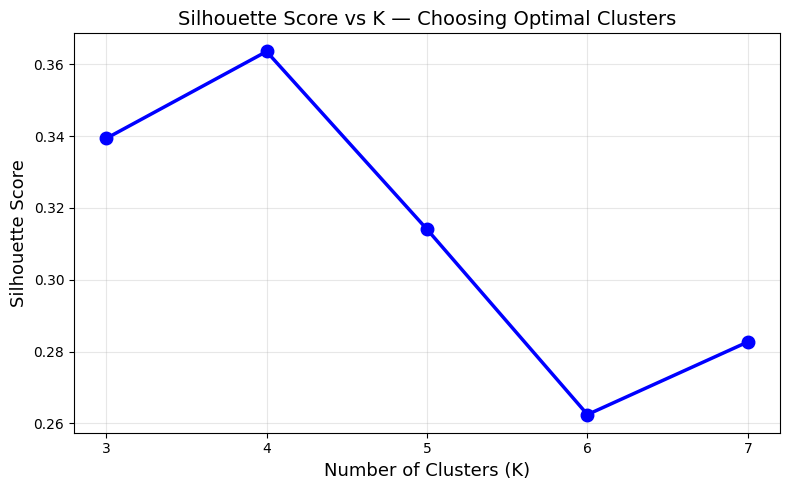

In [ ]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt

k_values = [3, 4, 5, 6, 7]
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        featuresCol="scaled_features",
        predictionCol="cluster",
        k=k,
        seed=42,
        maxIter=30
    )

    model = kmeans.fit(df)
    pred = model.transform(df)

    evaluator = ClusteringEvaluator(
        featuresCol="scaled_features",
        predictionCol="cluster",
        metricName="silhouette"
    )

    score = evaluator.evaluate(pred)
    silhouette_scores.append(score)
    print(f"K={k} -> Silhouette Score = {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, 'bo-', linewidth=2.5, markersize=9)
plt.xlabel("Number of Clusters (K)", fontsize=13)
plt.ylabel("Silhouette Score", fontsize=13)
plt.title("Silhouette Score vs K — Choosing Optimal Clusters", fontsize=14)
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("silhouette_scores.png", dpi=150)
plt.show()

In [ ]:
BEST_K = 4

kmeans_final = KMeans(
    featuresCol="scaled_features",
    predictionCol="cluster",
    k=BEST_K,
    seed=42,
    maxIter=50
)

kmeans_model = kmeans_final.fit(df)
df = kmeans_model.transform(df)

print("Cluster Distribution:")
df.groupBy("cluster").count().orderBy("cluster").show()

Cluster Distribution:
+-------+------+
|cluster| count|
+-------+------+
|      0|187742|
|      1|308442|
|      2| 26514|
|      3| 54320|
+-------+------+



In [ ]:
# Cluster name mapping — based on audio fingerprint analysis
cluster_names = {
    0: "Acoustic / Vintage Style",
    1: "Modern Pop & Dance",
    2: "Rap & Spoken Word",
    3: "Classical / Instrumental"
}

print("Cluster names defined:")
for k, v in cluster_names.items():
    print(f"  Cluster {k} → {v}")

Cluster names defined:
  Cluster 0 → Acoustic / Vintage Style
  Cluster 1 → Modern Pop & Dance
  Cluster 2 → Rap & Spoken Word
  Cluster 3 → Classical / Instrumental


In [ ]:
from pyspark.sql.functions import avg, round as spark_round

print("=" * 45)
print("CLUSTER AUDIO FINGERPRINTS")
print("=" * 45)

df.groupBy("cluster").agg(
    spark_round(avg("danceability"), 3).alias("danceability"),
    spark_round(avg("energy"), 3).alias("energy"),
    spark_round(avg("acousticness"), 3).alias("acousticness"),
    spark_round(avg("valence"), 3).alias("valence"),
    spark_round(avg("instrumentalness"), 3).alias("instrumentalness"),
    spark_round(avg("speechiness"), 3).alias("speechiness"),
    spark_round(avg("liveness"), 3).alias("liveness"),
    spark_round(avg("tempo"), 1).alias("tempo"),
    spark_round(avg("loudness"), 1).alias("loudness")
).orderBy("cluster").show()

CLUSTER AUDIO FINGERPRINTS
+-------+------------+------+------------+-------+----------------+-----------+--------+-----+--------+
|cluster|danceability|energy|acousticness|valence|instrumentalness|speechiness|liveness|tempo|loudness|
+-------+------------+------+------------+-------+----------------+-----------+--------+-----+--------+
|      0|         0.5|  0.34|       0.708|  0.436|           0.022|      0.055|   0.197|112.9|   -12.3|
|      1|       0.617| 0.723|       0.215|  0.654|           0.057|      0.079|   0.215|125.0|    -7.3|
|      2|       0.664| 0.404|       0.633|  0.565|           0.005|      0.852|   0.389|102.3|   -15.3|
|      3|       0.426| 0.283|       0.801|  0.391|           0.801|      0.058|   0.186|108.9|   -16.8|
+-------+------------+------+------------+-------+----------------+-----------+--------+-----+--------+



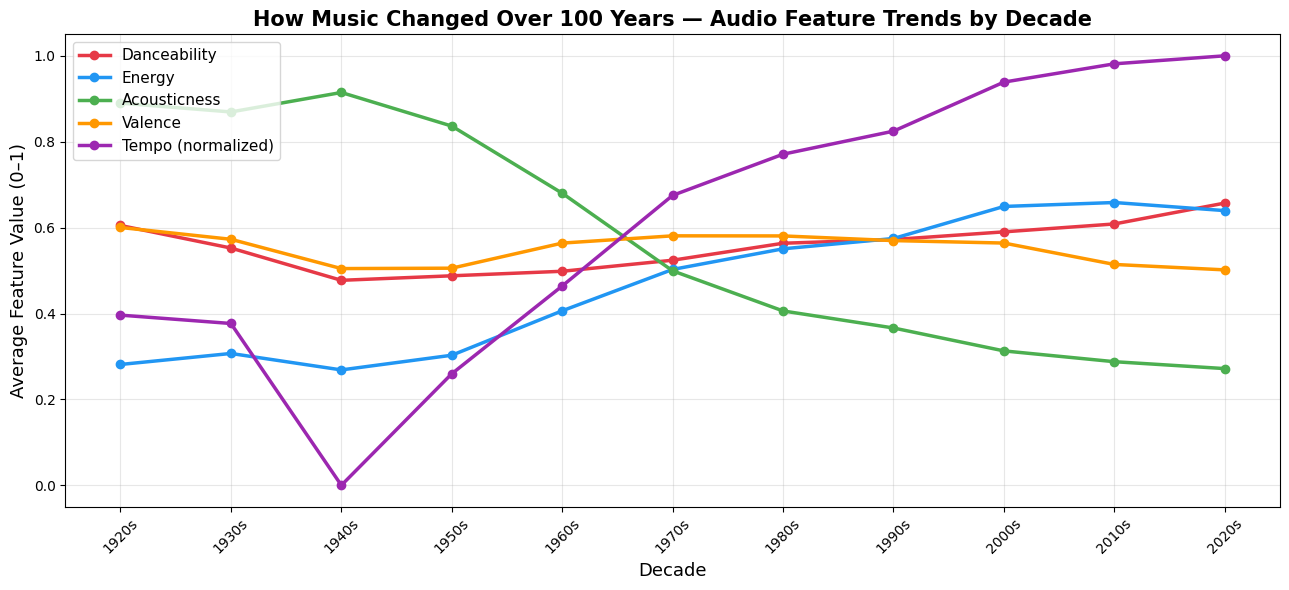

In [ ]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import avg

trend = df.groupBy("decade").agg(
    avg("danceability").alias("danceability"),
    avg("energy").alias("energy"),
    avg("acousticness").alias("acousticness"),
    avg("valence").alias("valence"),
    avg("tempo").alias("tempo")
).orderBy("decade").toPandas()

trend["tempo_norm"] = (trend["tempo"] - trend["tempo"].min()) / (trend["tempo"].max() - trend["tempo"].min())

fig, ax = plt.subplots(figsize=(13, 6))

features_to_plot = {
    "danceability": "#E63946",
    "energy": "#2196F3",
    "acousticness": "#4CAF50",
    "valence": "#FF9800",
    "tempo_norm": "#9C27B0"
}

labels = {
    "danceability": "Danceability",
    "energy": "Energy",
    "acousticness": "Acousticness",
    "valence": "Valence",
    "tempo_norm": "Tempo (normalized)"
}

for feat, color in features_to_plot.items():
    ax.plot(
        trend["decade"],
        trend[feat],
        marker='o',
        linewidth=2.5,
        markersize=6,
        color=color,
        label=labels[feat]
    )

ax.set_xlabel("Decade", fontsize=13)
ax.set_ylabel("Average Feature Value (0–1)", fontsize=13)
ax.set_title("How Music Changed Over 100 Years — Audio Feature Trends by Decade", fontsize=15, fontweight="bold")
ax.legend(fontsize=11, loc="upper left")
ax.grid(True, alpha=0.3)
ax.set_xticks(trend["decade"])
ax.set_xticklabels([str(d) + "s" for d in trend["decade"]], rotation=45)

plt.tight_layout()
plt.savefig("audio_trends.png", dpi=150)
plt.show()

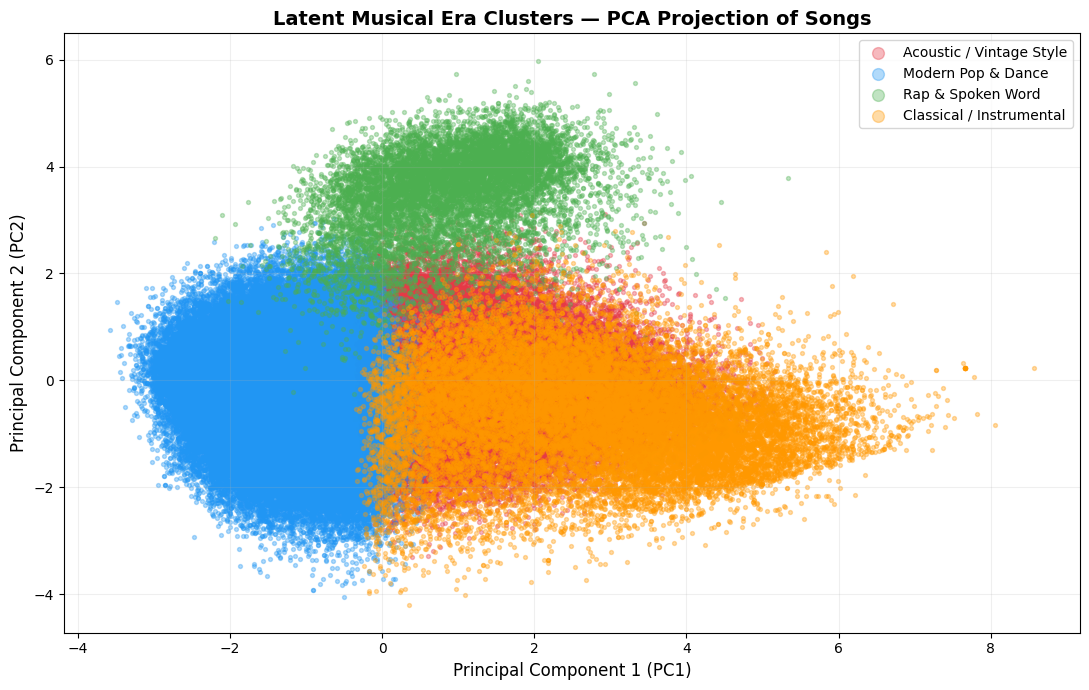

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

sample_pdf = df.select("pc1", "pc2", "cluster", "decade") \
    .sample(fraction=0.4, seed=42) \
    .toPandas()

cluster_colors = {
    0: "#E63946",
    1: "#2196F3",
    2: "#4CAF50",
    3: "#FF9800"
}

fig, ax = plt.subplots(figsize=(11, 7))

for cluster_id in sorted(sample_pdf["cluster"].unique()):
    subset = sample_pdf[sample_pdf["cluster"] == cluster_id]
    ax.scatter(subset["pc1"], subset["pc2"],
               c=cluster_colors.get(cluster_id, "grey"),
               label=cluster_names.get(cluster_id, f"Cluster {cluster_id}"),
               alpha=0.35, s=8)

ax.set_xlabel("Principal Component 1 (PC1)", fontsize=12)
ax.set_ylabel("Principal Component 2 (PC2)", fontsize=12)
ax.set_title("Latent Musical Era Clusters — PCA Projection of Songs", fontsize=14, fontweight="bold")
ax.legend(fontsize=10, markerscale=3)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("pca_clusters.png", dpi=150)
plt.show()

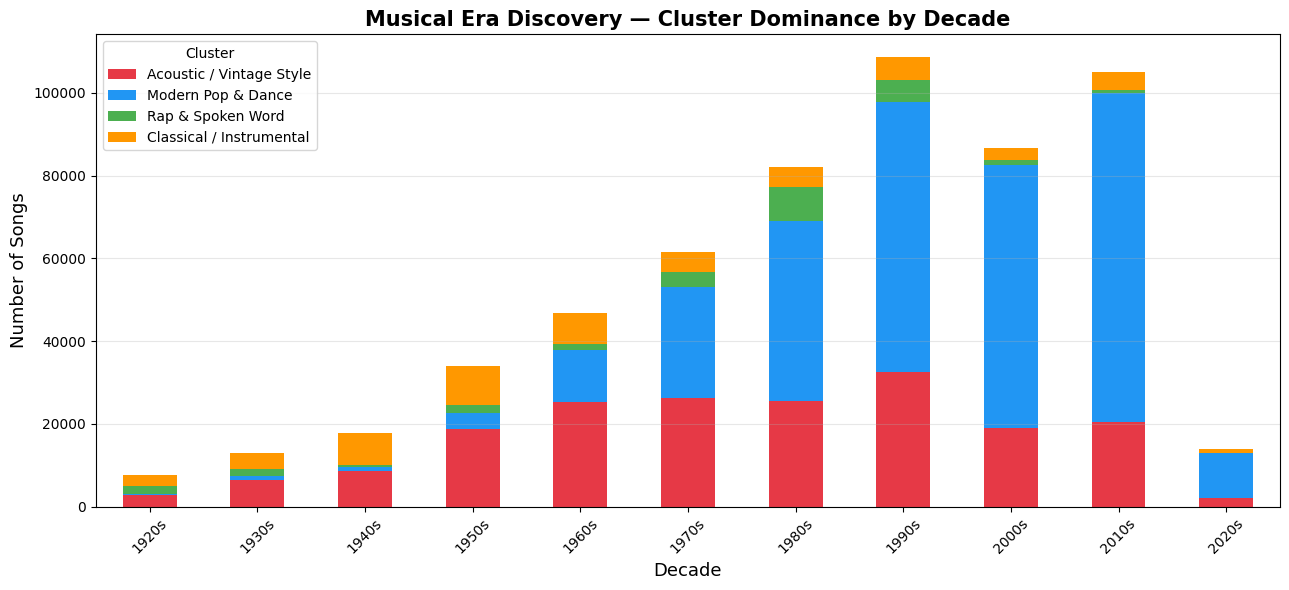

In [ ]:
import matplotlib.pyplot as plt

cluster_decade = df.groupBy("decade", "cluster").count()

pivot_pd = cluster_decade.groupBy("decade") \
    .pivot("cluster") \
    .sum("count") \
    .orderBy("decade") \
    .toPandas()

pivot_pd = pivot_pd.fillna(0)
pivot_pd = pivot_pd.set_index("decade")
pivot_pd.columns = [
    cluster_names.get(int(c), f"Cluster {c}")
    for c in pivot_pd.columns
]

colors = ["#E63946", "#2196F3", "#4CAF50", "#FF9800"]

ax = pivot_pd.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 6),
    color=colors[:len(pivot_pd.columns)]
)

ax.set_title("Musical Era Discovery — Cluster Dominance by Decade", fontsize=15, fontweight="bold")
ax.set_xlabel("Decade", fontsize=13)
ax.set_ylabel("Number of Songs", fontsize=13)
ax.set_xticklabels([str(int(d)) + "s" for d in pivot_pd.index], rotation=45)
ax.legend(title="Cluster")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("cluster_by_decade.png", dpi=150)
plt.show()

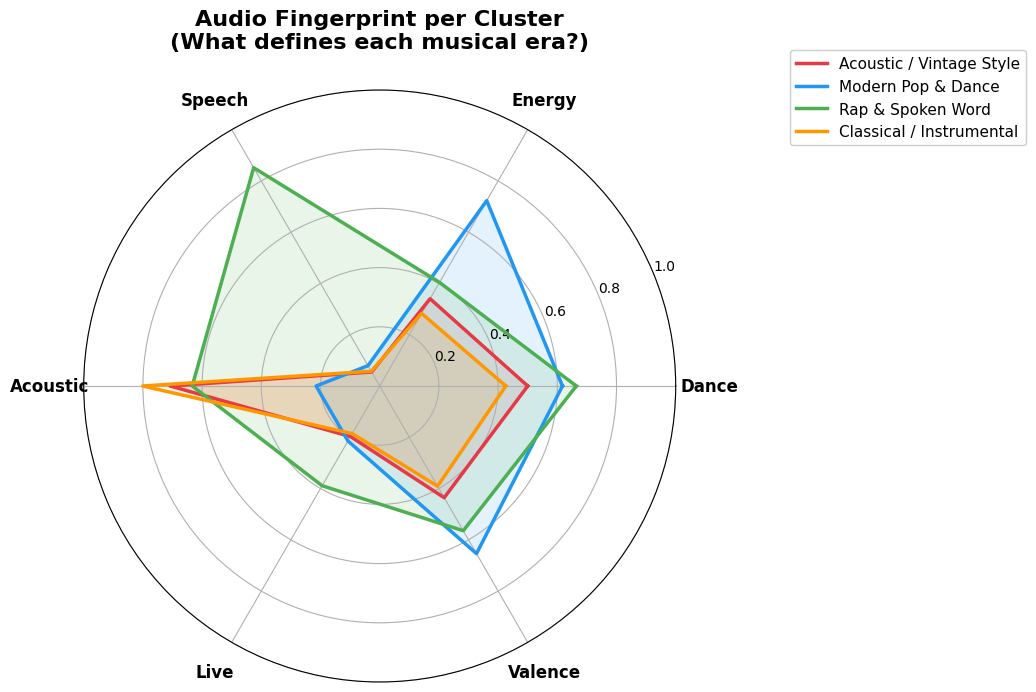

Saved: radar_chart.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql.functions import avg

radar_features = [
    "danceability", "energy", "speechiness",
    "acousticness", "liveness", "valence"
]

# Short labels just for radar chart
pretty_labels = {
    "danceability": "Dance",
    "energy": "Energy",
    "speechiness": "Speech",
    "acousticness": "Acoustic",
    "liveness": "Live",
    "valence": "Valence"
}

cluster_means = df.groupBy("cluster") \
    .agg(*[avg(f).alias(f) for f in radar_features]) \
    .orderBy("cluster") \
    .toPandas()

angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]

colors = ["#E63946", "#2196F3", "#4CAF50", "#FF9800"]

fig, ax = plt.subplots(figsize=(13, 8), subplot_kw=dict(polar=True))

for _, row in cluster_means.iterrows():
    cid = int(row["cluster"])
    values = [row[f] for f in radar_features]
    values += values[:1]

    ax.plot(
        angles, values,
        color=colors[cid],
        linewidth=2.5,
        label=cluster_names.get(cid, f"Cluster {cid}")
    )
    ax.fill(angles, values, color=colors[cid], alpha=0.12)

# Use built-in xticks with short labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(
    [pretty_labels[f] for f in radar_features],
    fontsize=12,
    fontweight="bold"
)

# Push labels a bit outward
ax.tick_params(axis="x", pad=14)

ax.set_ylim(0, 1)

# Cleaner grid/value labels
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=10)

ax.set_title(
    "Audio Fingerprint per Cluster\n(What defines each musical era?)",
    fontsize=16,
    fontweight="bold",
    pad=30
)

# Put legend clearly outside
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.18, 1.08),
    fontsize=11,
    framealpha=0.95
)

# Manually reserve space for legend and title
plt.subplots_adjust(left=0.08, right=0.72, top=0.82, bottom=0.08)

plt.savefig("radar_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: radar_chart.png")

In [ ]:
from pyspark.sql.window import Window
from pyspark.sql.functions import rank

dominant = df.groupBy("decade", "cluster").count() \
    .orderBy("decade", col("count").desc())

window = Window.partitionBy("decade").orderBy(col("count").desc())

dominant = dominant.withColumn("rank", rank().over(window)) \
    .filter(col("rank") == 1) \
    .select("decade", "cluster", "count") \
    .orderBy("decade")

print("=" * 45)
print("DECADE | DOMINANT CLUSTER | SONG COUNT")
print("=" * 45)
dominant.show(20)
# Print named version of era table
print("\n=== ERA DISCOVERY — WITH CLUSTER NAMES ===")
dominant_pd = dominant.toPandas()
dominant_pd["cluster_name"] = dominant_pd["cluster"].map(cluster_names)
print(dominant_pd[["decade", "cluster_name", "count"]].to_string(index=False))


DECADE | DOMINANT CLUSTER | SONG COUNT
+------+-------+-----+
|decade|cluster|count|
+------+-------+-----+
|  1920|      0| 2731|
|  1930|      0| 6372|
|  1940|      0| 8528|
|  1950|      0|18766|
|  1960|      0|25201|
|  1970|      1|26852|
|  1980|      1|43604|
|  1990|      1|65065|
|  2000|      1|63523|
|  2010|      1|79572|
|  2020|      1|10826|
+------+-------+-----+

This table is your 'machine-discovered era' story.


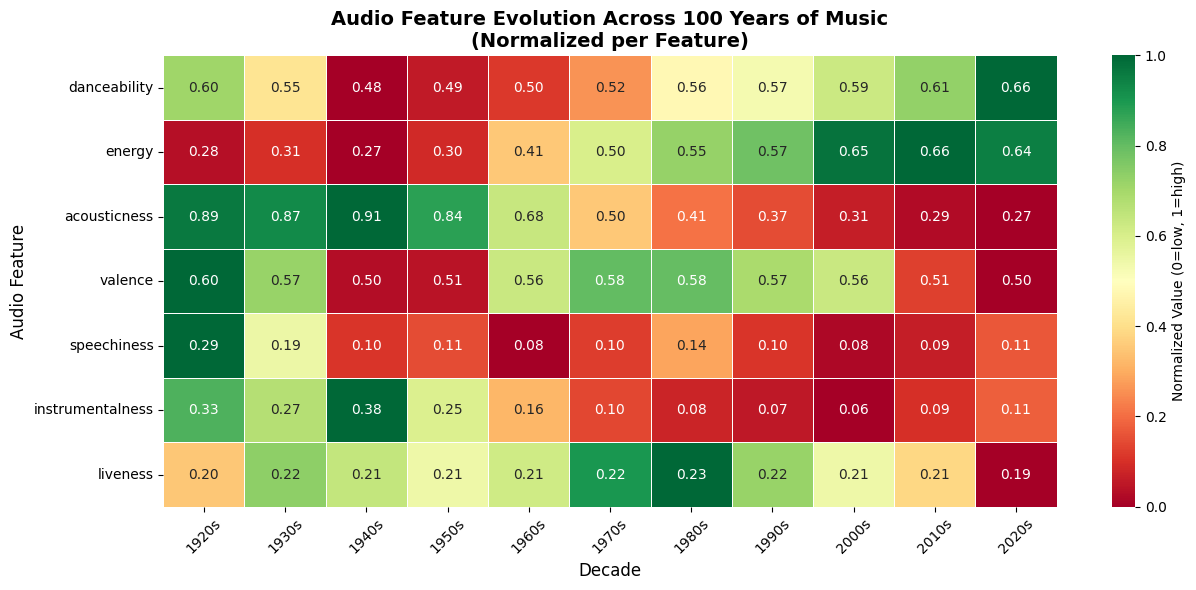

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql.functions import avg

heat_features = [
    "danceability",
    "energy",
    "acousticness",
    "valence",
    "speechiness",
    "instrumentalness",
    "liveness"
]

heat_data = df.groupBy("decade").agg(
    *[avg(f).alias(f) for f in heat_features]
).orderBy("decade").toPandas()

heat_data = heat_data.set_index("decade")

# normalize each feature across decades for easier comparison
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min())

plt.figure(figsize=(13, 6))
sns.heatmap(
    heat_norm.T,
    annot=heat_data.T.round(2),
    fmt=".2f",
    cmap="RdYlGn",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Normalized Value (0=low, 1=high)"}
)

plt.title("Audio Feature Evolution Across 100 Years of Music\n(Normalized per Feature)", fontsize=14, fontweight="bold")
plt.ylabel("Audio Feature", fontsize=12)
plt.xlabel("Decade", fontsize=12)
plt.xticks(
    ticks=np.arange(len(heat_norm.index)) + 0.5,
    labels=[str(int(d)) + "s" for d in heat_norm.index],
    rotation=45
)

plt.tight_layout()
plt.savefig("feature_heatmap.png", dpi=150)
plt.show()

In [ ]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number

window = Window.partitionBy("cluster").orderBy(col("popularity").desc())

top_songs = df.withColumn("rank", row_number().over(window)) \
    .filter(col("rank") <= 5) \
    .select("cluster", "rank", "name", "artists", "year", "popularity") \
    .orderBy("cluster", "rank")

print("=== TOP 5 MOST POPULAR SONGS PER CLUSTER ===")
top_songs.show(20, truncate=False)

=== TOP 5 MOST POPULAR SONGS PER CLUSTER ===
+-------+----+-----------------------------------------------+---------------------------------------------------------------------+----+----------+
|cluster|rank|name                                           |artists                                                              |year|popularity|
+-------+----+-----------------------------------------------+---------------------------------------------------------------------+----+----------+
|0      |1   |Heartbreak Anniversary                         |['Giveon']                                                           |2020|94.0      |
|0      |2   |DÁKITI                                         |['Bad Bunny', 'Jhay Cortez']                                         |2020|92.0      |
|0      |3   |you broke me first                             |['Tate McRae']                                                       |2020|91.0      |
|0      |4   |What You Know Bout Love                        

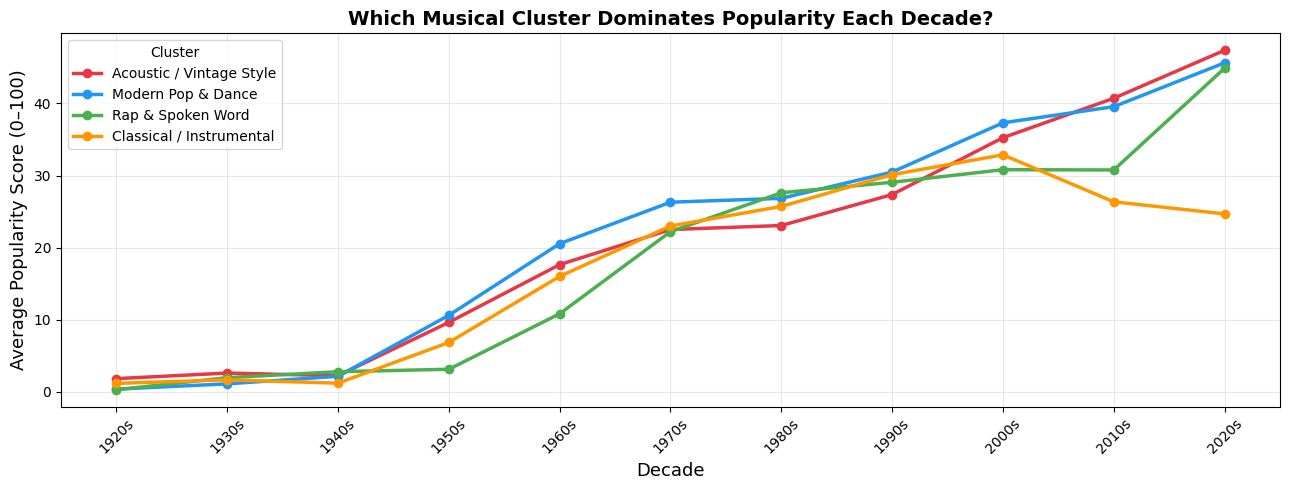

In [ ]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import avg

pop_trend = df.groupBy("decade", "cluster").agg(
    avg("popularity").alias("avg_popularity")
).orderBy("decade").toPandas()

fig, ax = plt.subplots(figsize=(13, 5))
colors = {0: "#E63946", 1: "#2196F3", 2: "#4CAF50", 3: "#FF9800"}

for cluster_id in sorted(pop_trend["cluster"].unique()):
    subset = pop_trend[pop_trend["cluster"] == cluster_id]
    ax.plot(
        subset["decade"],
        subset["avg_popularity"],
        marker='o',
        linewidth=2.5,
        color=colors[cluster_id],
        label=cluster_names.get(cluster_id, f"Cluster {cluster_id}")
    )

ax.set_xlabel("Decade", fontsize=13)
ax.set_ylabel("Average Popularity Score (0–100)", fontsize=13)
ax.set_title("Which Musical Cluster Dominates Popularity Each Decade?", fontsize=14, fontweight="bold")
ax.legend(title="Cluster")
ax.grid(True, alpha=0.3)
ax.set_xticks(sorted(pop_trend["decade"].unique()))
ax.set_xticklabels([str(int(d)) + "s" for d in sorted(pop_trend["decade"].unique())], rotation=45)

plt.tight_layout()
plt.savefig("popularity_by_cluster.png", dpi=150)
plt.show()

In [ ]:
print("=" * 55)
print("FINAL PROJECT SUMMARY")
print("=" * 55)

print(f"Total songs processed     : {df.count():,}")
print(f"Year range                : {df.agg({'year':'min'}).collect()[0][0]} - {df.agg({'year':'max'}).collect()[0][0]}")
print(f"Decades covered           : {df.select('decade').distinct().count()}")
print(f"Features used             : {len(feature_cols)} audio features")
print(f"PCA variance captured     : {sum(pca_model.explainedVariance)*100:.1f}%")
print(f"Optimal K (clusters)      : {BEST_K}")

print("\nCluster sizes:")
df.groupBy("cluster").count().orderBy("cluster").show()

print("Done.")

FINAL PROJECT SUMMARY
Total songs processed     : 577,018
Year range                : 1922 - 2020
Decades covered           : 11
Features used             : 9 audio features
PCA variance captured     : 47.9%
Optimal K (clusters)      : 4

Cluster sizes:
+-------+------+
|cluster| count|
+-------+------+
|      0|187742|
|      1|308442|
|      2| 26514|
|      3| 54320|
+-------+------+

Done.
